In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Searching in: /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered
Checking emotion folder: /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered/Jijik
  Counted 250 .wav files in /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered/Jijik
Checking emotion folder: /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered/Marah
  Counted 250 .wav files in /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered/Marah
Checking emotion folder: /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered/Netral
  Counted 250 .wav files in /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered/Netral
Checking emotion folder: /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered/Sedih
  Counted 250 .wav files in /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered/Sedih
Checking emotion folder: /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered/Takut
  Counted 250 .wav files in /content/drive/MyDrive/TADATA/FinalData/BigData_Filtered/Takut

Emotion Counts Dictionary:
{'Ji

/tmp/ipykernel_3042/1094484652.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_emotion = sns.barplot(data=plot_df_emotion, x='Emotion_en', y='Count', palette='gray') # Use English labels for x-axis


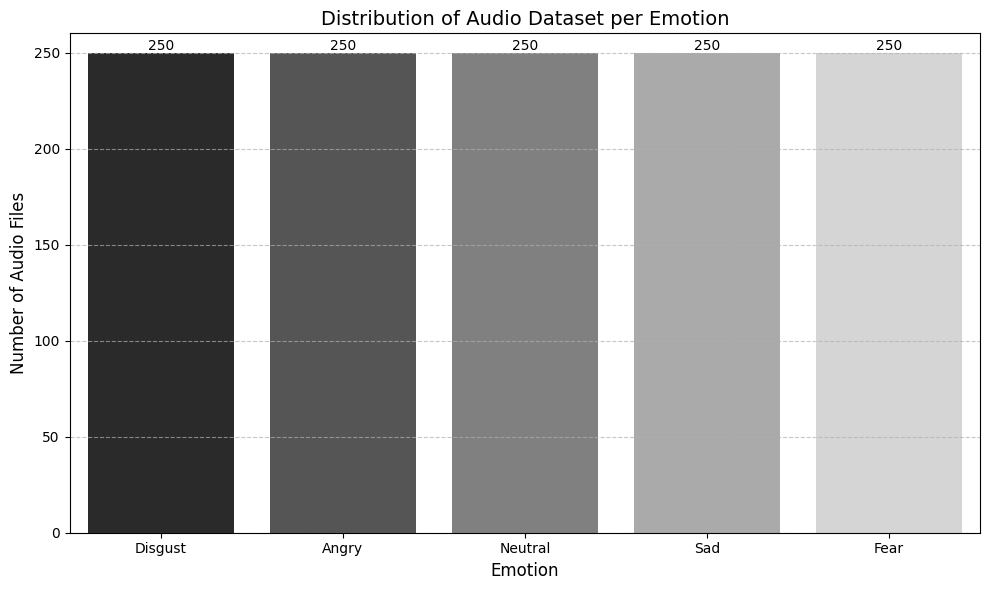

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Assuming the structure is labeled_data_root/Emotion/Audio_Files
labeled_data_root = '/content/drive/MyDrive/DATA500/Dataset'

# Define the emotion categories you are interested in
emotions = ["Jijik", "Marah", "Netral", "Sedih", "Takut"] # Keep Indonesian for folder traversal
emotions_en = ["Disgust", "Angry", "Neutral", "Sad", "Fear"] # English for plotting


# Dictionary to store counts for each emotion
# Structure: {emotion: count}
emotion_counts = {}

# Iterate through the main emotion folders
print(f"Searching in: {labeled_data_root}")
for emotion in emotions:
    emotion_folder_path = os.path.join(labeled_data_root, emotion)
    print(f"Checking emotion folder: {emotion_folder_path}")
    if os.path.exists(emotion_folder_path):
        # Count the audio files directly in the emotion folder
        audio_files_in_folder = [f for f in os.listdir(emotion_folder_path) if os.path.isfile(os.path.join(emotion_folder_path, f)) and f.endswith('.wav')]
        emotion_counts[emotion] = len(audio_files_in_folder)
        print(f"  Counted {len(audio_files_in_folder)} .wav files in {emotion_folder_path}")
    else:
        print(f"Emotion folder not found: {emotion_folder_path}")

print("\nEmotion Counts Dictionary:")
print(emotion_counts)


# Prepare data for plotting a bar chart showing emotion distribution
plot_data_emotion = []
for emotion in emotions:
    count = emotion_counts.get(emotion, 0) # Get count, default to 0 if emotion not found
    plot_data_emotion.append({'Emotion': emotion, 'Count': count})

print("\nPlot Data Emotion List:")
print(plot_data_emotion)

plot_df_emotion = pd.DataFrame(plot_data_emotion)

# Map Indonesian emotion labels to English for plotting
emotion_mapping = dict(zip(emotions, emotions_en))

# Check if DataFrame is empty before mapping and plotting
if not plot_df_emotion.empty:
    plot_df_emotion['Emotion_en'] = plot_df_emotion['Emotion'].map(emotion_mapping)

    # Create the bar plot for emotion distribution
    plt.figure(figsize=(10, 6))
    barplot_emotion = sns.barplot(data=plot_df_emotion, x='Emotion_en', y='Count', palette='gray') # Use English labels for x-axis

    plt.title('Distribution of Audio Dataset per Emotion', fontsize=14)
    plt.xlabel('Emotion', fontsize=12)
    plt.ylabel('Number of Audio Files', fontsize=12)
    plt.ylim(0, plot_df_emotion['Count'].max() + 10) # Adjust y-limit based on max count
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add counts on top of the bars
    for container in barplot_emotion.containers:
        barplot_emotion.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No data to plot for emotion distribution.")

# Removed film code specific plots as the structure doesn't include film code subfolders

# Removed overall distribution plot per film code as there are no film code subfolders

Reading and Extracting the Features
X shape: (3750, 180) | feature dim example = 180
Label mapping: {'Jijik': 0, 'Marah': 1, 'Netral': 2, 'Sedih': 3, 'Takut': 4}
Training: 3000 | Validation: 375 | Test: 375


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN-SER_TESS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 180, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 180, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 180, 128)       │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 180, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 180, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 22, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 22, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2816)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │        14,085 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 343,685 (1.31 MB)

 Trainable params: 343,685 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 234ms/step - accuracy: 0.3600 - loss: 1.9842 - val_accuracy: 0.4800 - val_loss: 1.2971
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 245ms/step - accuracy: 0.5223 - loss: 1.2747 - val_accuracy: 0.5493 - val_loss: 1.1889
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 241ms/step - accuracy: 0.5483 - loss: 1.2092 - val_accuracy: 0.6027 - val_loss: 1.1344
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 221ms/step - accuracy: 0.5657 - loss: 1.1566 - val_accuracy: 0.6293 - val_loss: 1.0914
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 246ms/step - accuracy: 0.5920 - loss: 1.1369 - val_accuracy: 0.6560 - val_loss: 1.0529
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 238ms/step - accuracy: 0.6057 - loss: 1.0945 - val_accuracy: 0.6347 - val_loss: 1.0628
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 245ms/step - accuracy: 0.6127 - loss: 1.0785 - val_accuracy: 0.6347 - val_loss: 1.0181
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.6360 - loss: 1.0450 - 

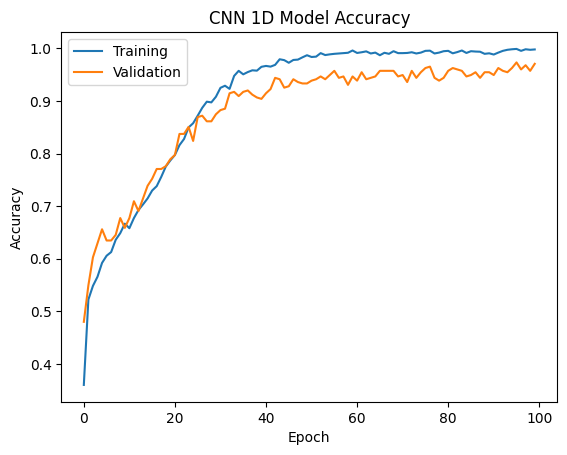

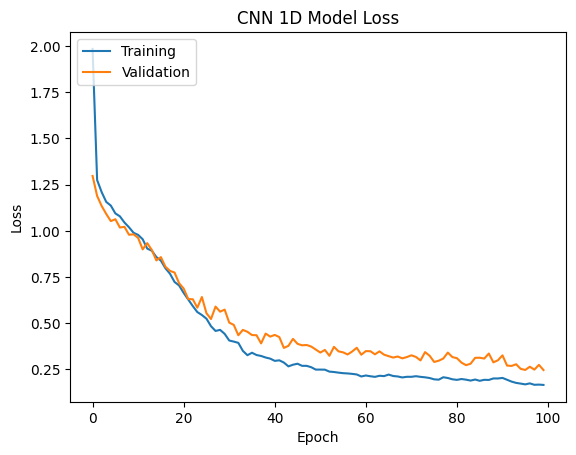

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
              precision    recall  f1-score   support

       Jijik     0.9375    1.0000    0.9677        75
       Marah     1.0000    0.9467    0.9726        75
      Netral     0.9211    0.9333    0.9272        75
       Sedih     0.9079    0.9200    0.9139        75
       Takut     0.9444    0.9067    0.9252        75

    accuracy                         0.9413       375
   macro avg     0.9422    0.9413    0.9413       375
weighted avg     0.9422    0.9413    0.9413       375



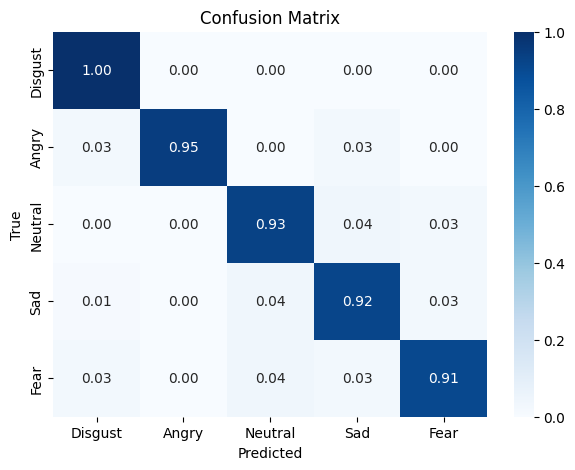

F1 (weighted): 0.9413148691772231


Saved to:  /content/drive/MyDrive/TADATA/Models/CNN1DBasic/CNN-SER_TESS.h5


In [ ]:
import os, glob, numpy as np, librosa, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd, seaborn as sn
import tensorflow as tf
from tensorflow.keras import layers, Sequential, regularizers
np.random.seed(42); tf.random.set_seed(42)

database_path = '/content/drive/MyDrive/DATA500/Dataset'
classes = ['Jijik', 'Marah', 'Netral', 'Sedih', 'Takut']
label_encode = {c:i for i,c in enumerate(classes)}

SR = 16000
N_MFCC = 40
N_MELS = 128
USE_AUG_NOISE = True
USE_AUG_SHIFT = True
WIN_S, HOP_S = 0.025, 0.0125
N_FFT = 512
WIN = int(round(WIN_S * SR))
HOP = int(round(HOP_S * SR))
pe_coeff = 0.97

# Data Augmentation
def add_noise(y, noise_factor=0.01):
    n = np.random.randn(len(y))
    return (y + noise_factor * n).astype(y.dtype)

def shift_wave(y, sr, shift_max=0.25, mode='right'):
    max_shift = int(sr * shift_max)
    shift = np.random.randint(max_shift+1)
    if mode == 'right':
        shift = -shift
    elif mode == 'both':
        if np.random.randint(2) == 1:
            shift = -shift
    y_roll = np.roll(y, shift)
    if shift > 0:
        y_roll[:shift] = 0
    else:
        y_roll[shift:] = 0
    return y_roll


# Feature Extraction
def pre_emphasis(y, pe_coeff):
    return np.append(y[0], y[1:] - pe_coeff*y[:-1])

def extract_feature_1d(y, sr, use_mfcc=True, use_chroma=True, use_mel=True):
    if len(y) < WIN:  # Pre-Emphasis
        y = np.pad(y, (0, WIN - len(y)), mode="constant")
    y = pre_emphasis(y, pe_coeff)
    feats = []


    stft = None # STFT
    if use_chroma:
        stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP,
                            win_length=WIN, window='hamm', center=True)
        mag = np.abs(stft) + 1e-10
    else:
        mag = None


    if use_mfcc: # MFCC
        mfcc = librosa.feature.mfcc(
            y=y, sr=sr, n_mfcc=N_MFCC,
            n_fft=N_FFT, hop_length=HOP, win_length=WIN, window='hamm'
        )
        feats.append(np.mean(mfcc, axis=1))

    if use_chroma: # Chroma
        chroma = librosa.feature.chroma_stft(
            S=mag, sr=sr, n_fft=N_FFT, hop_length=HOP, tuning=None
        )
        feats.append(np.mean(chroma, axis=1))


    if use_mel: # Mel-Filter Bank
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
            window='hamm', n_mels=N_MELS, power=2.0, fmin=0.0, fmax=sr/2
        )
        mel_db = librosa.power_to_db(mel, ref=1.0)
        feats.append(np.mean(mel_db, axis=1))

    return np.hstack(feats).astype(np.float32)

def load_audio(path, sr=SR):
    y, _ = librosa.load(path, sr=sr, mono=True, res_type='scipy')
    return y

# Load Dataset
def load_dataset(root_dir, save_numpy=True):
    X, y = [], []
    for emo in classes:
        emo_dir = os.path.join(root_dir, emo)
        if not os.path.isdir(emo_dir):
            continue
        for wav in glob.glob(os.path.join(emo_dir, '**', '*.wav'), recursive=True):
            data = load_audio(wav, SR)
            # Main Feature
            feat = extract_feature_1d(data, SR, True, True, True)
            X.append(feat); y.append(emo)

            # Augmetation : Noise
            if USE_AUG_NOISE:
                n_data = add_noise(data, 0.001)
                n_feat = extract_feature_1d(n_data, SR, True, True, True)
                X.append(n_feat); y.append(emo)

            # Augmentation : Shift
            if USE_AUG_SHIFT:
                s_data = shift_wave(data, SR, 0.25, 'right')
                s_feat = extract_feature_1d(s_data, SR, True, True, True)
                X.append(s_feat); y.append(emo)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=object)
    if save_numpy:
        np.save('X.npy', X); np.save('y.npy', y)
    return X, y

print("Reading and Extracting the Features")
X, y_names = load_dataset(database_path, save_numpy=True)
print("X shape:", X.shape, "| feature dim example =", X.shape[1])

# Label Encoding
le = LabelEncoder()
le.fit(y_names)
y = le.transform(y_names)
n_classes = len(le.classes_)
print("Label mapping:", dict(zip(le.classes_, range(n_classes))))

# Data Splitting
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)
print(f"Training: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

# Reshape Conv1D (N, time, channels)
Xtr = np.expand_dims(X_train, axis=2)
Xva = np.expand_dims(X_val,   axis=2)
Xte = np.expand_dims(X_test,  axis=2)

# CNN Modeling
model_name = "CNN-SER_TESS"
model = Sequential(name = model_name)
model.add(layers.Conv1D(256, 5, padding='same', input_shape=(Xtr.shape[1], 1)))
model.add(layers.Activation('relu'))

model.add(layers.Conv1D(128, 5, padding='same',kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.1))
model.add(layers.MaxPooling1D(pool_size=8))

model.add(layers.Conv1D(128, 5, padding='same',kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)))
model.add(layers.Activation('relu'))

model.add(layers.Conv1D(128, 5, padding='same',kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Flatten())
model.add(layers.Dense(n_classes, kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4), bias_regularizer=regularizers.l2(1e-4), activity_regularizer=regularizers.l2(1e-5)))
model.add(layers.Activation('softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
model.summary()

# Train the Model
history = model.fit(
    Xtr, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(Xva, y_val),
    verbose=1
)

# Plot Training Result
plt.figure(); plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy'])
plt.title('CNN 1D Model Accuracy'); plt.ylabel('Accuracy'); plt.xlabel('Epoch')
plt.legend(['Training','Validation'], loc='upper left'); plt.show()

plt.figure(); plt.plot(history.history['loss']); plt.plot(history.history['val_loss'])
plt.title('CNN 1D Model Loss'); plt.ylabel('Loss'); plt.xlabel('Epoch')
plt.legend(['Training','Validation'], loc='upper left'); plt.show()

# Model Evaluation
Xte_proc = Xte
y_pred_prob = model.predict(Xte_proc)
y_pred = np.argmax(y_pred_prob, axis=-1)

print(classification_report(y_test, y_pred, target_names=list(le.classes_), digits=4))
cm = confusion_matrix(y_test, y_pred)

# Normalize confusion matrix to show probabilities
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
class_names_en = ["Disgust", "Angry", "Neutral", "Sad", "Fear"]

df_cm = pd.DataFrame(cm_normalized, index=class_names_en, columns=class_names_en)
plt.figure(figsize=(7,5)); sn.heatmap(df_cm, annot=True, fmt='.2f', cmap='Blues')
plt.title('Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted'); plt.show()

print("F1 (weighted):", f1_score(y_test, y_pred, average='weighted'))

# Save Model
os.makedirs('/content/drive/MyDrive/TADATA/Models1211/CNN1DBasic', exist_ok=True)
save_path = f'/content/drive/MyDrive/TADATA/Models1211/CNN1DBasic/{model_name}.h5'
model.save(save_path)
print("Saved to: ", save_path)

Reading and Extracting the Features


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


X shape: (7500, 180) | feature dim example = 180
Label mapping: {'Jijik': 0, 'Marah': 1, 'Netral': 2, 'Sedih': 3, 'Takut': 4}
Training: 6000 | Validation: 750 | Test: 750


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN-SER_TESS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 180, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 180, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 180, 128)       │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 180, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 180, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 22, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 22, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2816)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │        14,085 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 343,685 (1.31 MB)

 Trainable params: 343,685 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 374ms/step - accuracy: 0.4067 - loss: 1.7237 - val_accuracy: 0.5040 - val_loss: 1.3247
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 384ms/step - accuracy: 0.4985 - loss: 1.3162 - val_accuracy: 0.5373 - val_loss: 1.2691
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 413ms/step - accuracy: 0.5260 - loss: 1.2655 - val_accuracy: 0.5427 - val_loss: 1.2511
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 35s 376ms/step - accuracy: 0.5433 - loss: 1.2384 - val_accuracy: 0.5627 - val_loss: 1.2056
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 373ms/step - accuracy: 0.5608 - loss: 1.2025 - val_accuracy: 0.5933 - val_loss: 1.1639
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 379ms/step - accuracy: 0.5787 - loss: 1.1706 - val_accuracy: 0.6027 - val_loss: 1.1572
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 49s 467ms/step - accuracy: 0.5968 - loss: 1.1265 - val_accuracy: 0.5920 - val_loss: 1.1449
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 35s 373ms/step - accuracy: 0.6080 - loss: 1.1127 - 

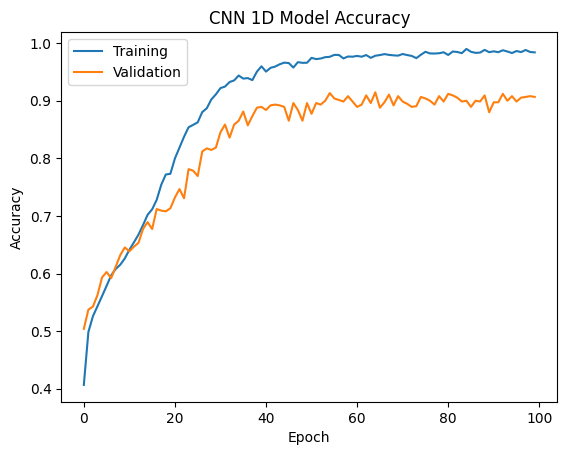

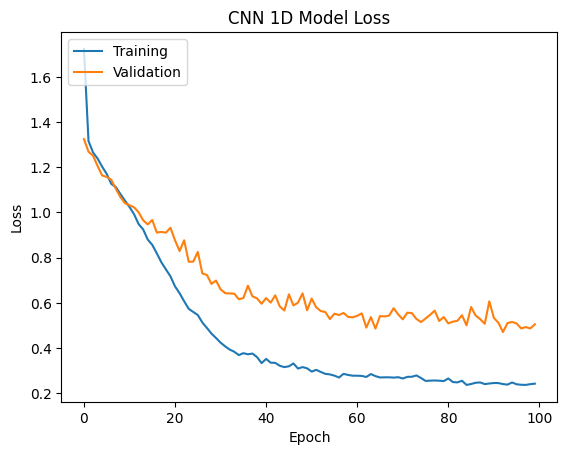

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
              precision    recall  f1-score   support

       Jijik     0.9474    0.9600    0.9536       150
       Marah     0.9375    0.9000    0.9184       150
      Netral     0.8571    0.8800    0.8684       150
       Sedih     0.8716    0.8600    0.8658       150
       Takut     0.8684    0.8800    0.8742       150

    accuracy                         0.8960       750
   macro avg     0.8964    0.8960    0.8961       750
weighted avg     0.8964    0.8960    0.8961       750



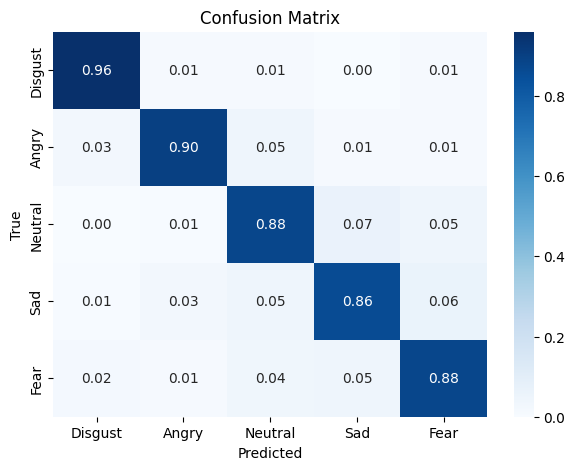

F1 (weighted): 0.8960749562374631
Saved to:  /content/drive/MyDrive/TADATA/Models1211/CNN1DBasic/CNN-SER_TESS.h5


In [ ]:
import os, glob, numpy as np, librosa, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd, seaborn as sn
import tensorflow as tf
from tensorflow.keras import layers, Sequential, regularizers
np.random.seed(42); tf.random.set_seed(42)

database_path = '/content/drive/MyDrive/DATA500/Dataset'
classes = ['Jijik', 'Marah', 'Netral', 'Sedih', 'Takut']
label_encode = {c:i for i,c in enumerate(classes)}

SR = 16000
N_MFCC = 40
N_MELS = 128
USE_AUG_NOISE = True
USE_AUG_SHIFT = True
WIN_S, HOP_S = 0.025, 0.0125
N_FFT = 512
WIN = int(round(WIN_S * SR))
HOP = int(round(HOP_S * SR))
pe_coeff = 0.97

# Data Augmentation
def add_noise(y, noise_factor=0.01):
    n = np.random.randn(len(y))
    return (y + noise_factor * n).astype(y.dtype)

def shift_wave(y, sr, shift_max=0.25, mode='right'):
    max_shift = int(sr * shift_max)
    shift = np.random.randint(max_shift+1)
    if mode == 'right':
        shift = -shift
    elif mode == 'both':
        if np.random.randint(2) == 1:
            shift = -shift
    y_roll = np.roll(y, shift)
    if shift > 0:
        y_roll[:shift] = 0
    else:
        y_roll[shift:] = 0
    return y_roll


# Feature Extraction
def pre_emphasis(y, pe_coeff):
    return np.append(y[0], y[1:] - pe_coeff*y[:-1])

def extract_feature_1d(y, sr, use_mfcc=True, use_chroma=True, use_mel=True):
    if len(y) < WIN:  # Pre-Emphasis
        y = np.pad(y, (0, WIN - len(y)), mode="constant")
    y = pre_emphasis(y, pe_coeff)
    feats = []


    stft = None # STFT
    if use_chroma:
        stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP,
                            win_length=WIN, window='hamm', center=True)
        mag = np.abs(stft) + 1e-10
    else:
        mag = None


    if use_mfcc: # MFCC
        mfcc = librosa.feature.mfcc(
            y=y, sr=sr, n_mfcc=N_MFCC,
            n_fft=N_FFT, hop_length=HOP, win_length=WIN, window='hamm'
        )
        feats.append(np.mean(mfcc, axis=1))

    if use_chroma: # Chroma
        chroma = librosa.feature.chroma_stft(
            S=mag, sr=sr, n_fft=N_FFT, hop_length=HOP, tuning=None
        )
        feats.append(np.mean(chroma, axis=1))


    if use_mel: # Mel-Filter Bank
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
            window='hamm', n_mels=N_MELS, power=2.0, fmin=0.0, fmax=sr/2
        )
        mel_db = librosa.power_to_db(mel, ref=1.0)
        feats.append(np.mean(mel_db, axis=1))

    return np.hstack(feats).astype(np.float32)

def load_audio(path, sr=SR):
    y, _ = librosa.load(path, sr=sr, mono=True, res_type='scipy')
    return y

# Load Dataset
def load_dataset(root_dir, save_numpy=True):
    X, y = [], []
    for emo in classes:
        emo_dir = os.path.join(root_dir, emo)
        if not os.path.isdir(emo_dir):
            continue
        for wav in glob.glob(os.path.join(emo_dir, '**', '*.wav'), recursive=True):
            data = load_audio(wav, SR)
            # Main Feature
            feat = extract_feature_1d(data, SR, True, True, True)
            X.append(feat); y.append(emo)

            # Augmetation : Noise
            if USE_AUG_NOISE:
                n_data = add_noise(data, 0.001)
                n_feat = extract_feature_1d(n_data, SR, True, True, True)
                X.append(n_feat); y.append(emo)

            # Augmentation : Shift
            if USE_AUG_SHIFT:
                s_data = shift_wave(data, SR, 0.25, 'right')
                s_feat = extract_feature_1d(s_data, SR, True, True, True)
                X.append(s_feat); y.append(emo)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=object)
    if save_numpy:
        np.save('X.npy', X); np.save('y.npy', y)
    return X, y

print("Reading and Extracting the Features")
X, y_names = load_dataset(database_path, save_numpy=True)
print("X shape:", X.shape, "| feature dim example =", X.shape[1])

# Label Encoding
le = LabelEncoder()
le.fit(y_names)
y = le.transform(y_names)
n_classes = len(le.classes_)
print("Label mapping:", dict(zip(le.classes_, range(n_classes))))

# Data Splitting
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)
print(f"Training: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

# Reshape Conv1D (N, time, channels)
Xtr = np.expand_dims(X_train, axis=2)
Xva = np.expand_dims(X_val,   axis=2)
Xte = np.expand_dims(X_test,  axis=2)

# CNN Modeling
model_name = "CNN-SER_TESS"
model = Sequential(name = model_name)
model.add(layers.Conv1D(256, 5, padding='same', input_shape=(Xtr.shape[1], 1)))
model.add(layers.Activation('relu'))

model.add(layers.Conv1D(128, 5, padding='same',kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.1))
model.add(layers.MaxPooling1D(pool_size=8))

model.add(layers.Conv1D(128, 5, padding='same',kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)))
model.add(layers.Activation('relu'))

model.add(layers.Conv1D(128, 5, padding='same',kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Flatten())
model.add(layers.Dense(n_classes, kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4), bias_regularizer=regularizers.l2(1e-4), activity_regularizer=regularizers.l2(1e-5)))
model.add(layers.Activation('softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
model.summary()

# Train the Model
history = model.fit(
    Xtr, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(Xva, y_val),
    verbose=1
)

# Plot Training Result
plt.figure(); plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy'])
plt.title('CNN 1D Model Accuracy'); plt.ylabel('Accuracy'); plt.xlabel('Epoch')
plt.legend(['Training','Validation'], loc='upper left'); plt.show()

plt.figure(); plt.plot(history.history['loss']); plt.plot(history.history['val_loss'])
plt.title('CNN 1D Model Loss'); plt.ylabel('Loss'); plt.xlabel('Epoch')
plt.legend(['Training','Validation'], loc='upper left'); plt.show()

# Model Evaluation
Xte_proc = Xte
y_pred_prob = model.predict(Xte_proc)
y_pred = np.argmax(y_pred_prob, axis=-1)

print(classification_report(y_test, y_pred, target_names=list(le.classes_), digits=4))
cm = confusion_matrix(y_test, y_pred)

# Normalize confusion matrix to show probabilities
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
class_names_en = ["Disgust", "Angry", "Neutral", "Sad", "Fear"]

df_cm = pd.DataFrame(cm_normalized, index=class_names_en, columns=class_names_en)
plt.figure(figsize=(7,5)); sn.heatmap(df_cm, annot=True, fmt='.2f', cmap='Blues')
plt.title('Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted'); plt.show()

print("F1 (weighted):", f1_score(y_test, y_pred, average='weighted'))

# Save Model
os.makedirs('/content/drive/MyDrive/TADATA/Models1211/CNN1DBasic', exist_ok=True)
save_path = f'/content/drive/MyDrive/TADATA/Models1211/CNN1DBasic/{model_name}.h5'
model.save(save_path)
print("Saved to: ", save_path)